# SDE MCMC — shape bridges with non-linear transitions

[Notebook 05](05_gaussian_bffg.ipynb) ran BFFG-guided MCMC under linear-Gaussian transitions, where the Theorem-14 importance weight collapses to 0. This notebook keeps the **same NumPyro driver + custom RW+pCN kernel pattern**, but **swaps the per-edge transition for a non-linear Kunita-style SDE on landmark configurations**. The result is a research-style shape-bridge MCMC, using the `hyperiax.prebuilt.bffg` `continuous_*` sweeps.

## The model

At every tree node lives a **shape** — a configuration of $n=16$ landmarks in $\mathbb{R}^2$, so the state at each node is a flat $n \cdot d = 32$-dimensional vector. Along each edge the shape evolves under a driftless SDE

$$dX_t \;=\; \sigma(X_t,\theta)\,dW_t, \qquad \sigma\sigma^\top = a(X_t,\theta),$$

where $\sigma(X,\theta)$ is given by a Laplace-2 reproducing kernel on landmark pairs (length scale $k_\sigma$ and amplitude $k_\alpha$). Leaves are observed as noisy snapshots of the terminal landmark configuration; we infer the kernel hyperparameters $\theta=(k_\alpha, k_\sigma)$ jointly with the latent bridge trajectories.

## How BFFG enters

Unlike the linear case, BFFG is **not exact** here:

- The **auxiliary process** for backward filtering is a *state-independent* linearisation: $\tilde\sigma$ is frozen at a single per-edge **anchor** point, initialised at the root shape and refined toward the BFFG posterior mean by the Algorithm 3 §7.1 iteration (`continuous_refine_anchor`).
- The closed-form *anlt* path (`continuous_bf_sweep` with `prxy_scale_fn=None, prxy_shift_fn=None`) propagates canonical messages $(\mathrm{prec}, \mathrm{ptnl}, \mathrm{log\_norm})$ up the tree under this approximation.
- The Theorem-23 importance correction $\sum \log w_v$ ([Remark 24 in the paper](https://arxiv.org/abs/2505.18239)) corrects for the discrepancy: it picks up genuine variance across noise draws, in contrast to the Theorem-14 collapse we saw in notebook 05.

The MCMC target is then

$$\pi(z, \log\theta) \;\propto\; p(z)\,p(\log\theta)\,\exp\!\bigl(\mathrm{log\_norm\_root}(\log\theta) + \sum_v \log w_v(z, \log\theta)\bigr),$$

where $\mathrm{log\_norm\_root}$ is the BFFG canonical message evaluated at the pinned root, $\log h(x_\text{root}) = c + F^\top x_\text{root} - \tfrac12 x_\text{root}^\top H x_\text{root}$. Same kernel as notebook 05: **pCN** on the noise field $z$, **RW** on $\log\theta$.

Model and algorithm from

> van der Meulen, F. H. & Sommer, S. (2025). *Backward Filtering Forward Guiding.* JMLR **26**(281), 1–51. [arXiv:2505.18239](https://arxiv.org/abs/2505.18239) — §7.1 / Theorem 23 / Remark 24.

## Outline

1. **Setup** (all inline) — tree topology, shape + kernel diffusion, true parameters and priors, schema, synthetic data, and the BFFG-guided forward map `init_continuous_tree → (continuous_bf_sweep → continuous_refine_anchor) ×N → continuous_fg_sweep`.
2. **Ground-truth bridges and a BFFG-guided draw.**
3. **The Theorem-23 importance weight** — non-zero under non-linear $\sigma$ (contrast with notebook 05's collapse).
4. **NumPyro model** wrapping the forward map.
5. **Custom `RWpCNKernel`** — pCN on the noise field $z$, RW on `(log_k_alpha, log_k_sigma)`.
6. **Run the chain.**
7. **Trace plots and posterior summaries.**
8. **Multi-chain convergence** — Gelman–Rubin $\hat R$ and ESS.

Recap.

## 1. Setup

Everything is inlined so this notebook is self-contained.

### Imports + tree topology

In [1]:
%matplotlib inline
import time
from collections import namedtuple

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC
from numpyro.infer.mcmc import MCMCKernel
from numpyro.infer.util import initialize_model
from numpyro.diagnostics import effective_sample_size, gelman_rubin

numpyro.set_host_device_count(4)

import hyperiax as hx
from hyperiax.prebuilt.bffg import (
    continuous_bf_sweep,
    continuous_fg_sweep,
    continuous_forward_sweep,
    continuous_refine_anchor,
    continuous_schema,
    init_continuous_tree,
)

# Depth-2 ternary tree: 1 root + 3 mid + 9 leaves = 13 nodes.
topo = hx.symmetric_topology(depth=2, degree=3)
N_NODES = topo.size
N_LEAVES = int(topo.is_leaf.sum())

print(f"tree: {N_NODES} nodes, {N_LEAVES} leaves, depth {topo.depth}")


tree: 13 nodes, 9 leaves, depth 2


/Users/vbd402/Projects/hyperiax/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Shape model — landmarks, kernel, SDE coefficients

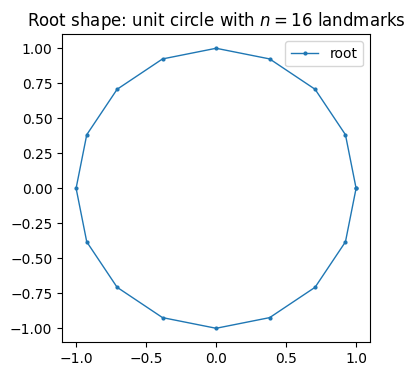

In [2]:
N_LANDMARKS, D_PER_LANDMARK = 16, 2
D = N_LANDMARKS * D_PER_LANDMARK   # state dim per node
N_STEPS = 100                      # SDE steps per edge

# Root shape: closed unit circle in 2D, flattened to (n*d,).
phis = jnp.linspace(0, 2 * jnp.pi, N_LANDMARKS, endpoint=False)
ROOT_SHAPE = jnp.vstack([jnp.cos(phis), jnp.sin(phis)]).T.flatten().astype(jnp.float32)


def kernel_matrix(q, params):
    # Laplace-2 reproducing kernel on landmark pairs -> (n, n) PSD matrix.
    pair_diff = (
        q.reshape((-1, D_PER_LANDMARK))[:, None, :]
        - q.reshape((-1, D_PER_LANDMARK))[None, :, :]
    )
    r = jnp.sqrt(jnp.sum((pair_diff / params["k_sigma"]) ** 2, axis=-1) + 1e-8)
    K = (
        params["k_alpha"]
        * (1.0 + r + (45 / 105) * r ** 2 + (10 / 105) * r ** 3 + (1 / 105) * r ** 4)
        * jnp.exp(-r)
    )
    return K


def drift_fn(t, x, params):
    return jnp.zeros(D)  # driftless: pure Kunita-style diffusion


def diffusion_fn(t, x, params):
    # Diffusion factor sigma = K kron I_d acting on the (n*d,) state.
    K = kernel_matrix(x, params)
    return jnp.kron(K, jnp.eye(D_PER_LANDMARK))


def prxy_diffusion_fn(t, anchor, params):
    # Auxiliary diffusion, frozen at the edge's linearisation point `anchor`
    # (refined toward the posterior mean by Algorithm 3 §7.1).
    K = kernel_matrix(anchor, params)
    return jnp.kron(K, jnp.eye(D_PER_LANDMARK))


def plot_shape(x, *, ax=None, color="C0", label=None, lw=1.0, alpha=1.0):
    if ax is None:
        _, ax = plt.subplots(figsize=(4, 4))
    pts = np.asarray(x).reshape((N_LANDMARKS, D_PER_LANDMARK))
    closed = np.vstack([pts, pts[:1]])
    ax.plot(closed[:, 0], closed[:, 1], "-o", color=color, label=label, lw=lw, ms=2, alpha=alpha)
    ax.set_aspect("equal")
    return ax


plot_shape(ROOT_SHAPE, color="C0", label="root")
plt.title(f"Root shape: unit circle with $n = {N_LANDMARKS}$ landmarks")
plt.legend(); plt.show()

### True parameters + MCMC constants

In [3]:
TAU_SQ_TRUE = 1e-3      # observation variance per landmark coordinate
PRIOR_LOG_MEAN = {"log_k_alpha": jnp.log(0.2), "log_k_sigma": jnp.log(0.5)}
PRIOR_STD = {"log_k_alpha": 0.7, "log_k_sigma": 0.7}   # log k ~ N(log mean, std**2)

PCN_ETA = 0.6           # pCN step size for the noise block
RW_SCALE = 0.1          # random-walk step in (log k_alpha, log k_sigma)

# Small k_alpha keeps the bridges close to the root shape, where the
# root-anchored auxiliary approximates the true sigma(X) well.
K_ALPHA_TRUE = 0.05
K_SIGMA_TRUE = 0.25
TRUE_PARAMS = {"k_alpha": jnp.array(K_ALPHA_TRUE, dtype=jnp.float32),
               "k_sigma": jnp.array(K_SIGMA_TRUE, dtype=jnp.float32)}

print(f"truth: k_alpha = {K_ALPHA_TRUE}, k_sigma = {K_SIGMA_TRUE}, tau² = {TAU_SQ_TRUE}")
print(f"prior on each log-param:\nlog_k_alpha ~ N({PRIOR_LOG_MEAN['log_k_alpha']}, {PRIOR_STD['log_k_alpha']}²)\nlog_k_sigma ~ N({PRIOR_LOG_MEAN['log_k_sigma']}, {PRIOR_STD['log_k_sigma']}²)")
print(f"kernel constants: pCN η = {PCN_ETA}, RW scale = {RW_SCALE}")

truth: k_alpha = 0.05, k_sigma = 0.25, tau² = 0.001
prior on each log-param:
log_k_alpha ~ N(-1.6094379425048828, 0.7²)
log_k_sigma ~ N(-0.6931471824645996, 0.7²)
kernel constants: pCN η = 0.6, RW scale = 0.1


### Schema + empty tree

In [4]:
SCHEMA = continuous_schema(d=D, n_steps=N_STEPS)
empty = hx.Tree.empty(topo, SCHEMA).set(edge_len=jnp.ones(N_NODES, dtype=jnp.float32))
# Pin root at the constant unit-circle trajectory across the n_steps+1 grid.
empty = empty.at[topo.is_root].set(
    vals=jnp.broadcast_to(ROOT_SHAPE, (N_STEPS + 1, D))
)

print(f"schema fields: {list(SCHEMA.keys())}")
print(f"state dim per node = {D};  noise per node = (n_steps, D) = ({N_STEPS}, {D})")


schema fields: ['edge_len', 'vals', 'zs', 'ptnls', 'precs', 'ptnl_v', 'prec_v', 'anchor', 'anchor_pa', 'log_norm', 'log_corr']
state dim per node = 32;  noise per node = (n_steps, D) = (100, 32)


### Synthetic data — forward simulation under the truth

`continuous_forward_sweep` walks root -> leaves drawing each bridge under the true `(drift_fn, diffusion_fn)` via Euler-Maruyama. We take the terminal landmark configuration at every leaf and corrupt it with iid Gaussian noise of variance $\tau^2$.

In [5]:
_sweep_forward = continuous_forward_sweep(N_STEPS, drift_fn, diffusion_fn)

k_path, k_obs = jax.random.split(jax.random.PRNGKey(202605), 2)
_gt = empty.set(zs=jax.random.normal(k_path, (N_NODES, N_STEPS, D), dtype=jnp.float32))
_gt = _sweep_forward(_gt, params=TRUE_PARAMS)

leaf_truth = _gt.vals[topo.is_leaf, -1]
_obs_noise = jnp.sqrt(TAU_SQ_TRUE) * jax.random.normal(k_obs, leaf_truth.shape, dtype=jnp.float32)
leaf_obs = leaf_truth + _obs_noise   # (N_LEAVES, D)
print(f"leaf_obs.shape = {leaf_obs.shape}")


leaf_obs.shape = (9, 32)


### BFFG-guided forward map (Algorithm 3 with iterative linearisation)

Four sweeps from `hyperiax.prebuilt.bffg.continuous_*`:

- **`init_continuous_tree`** — seeds the leaf vertex messages $(H_\ell = I/\tau^2,\, F_\ell = y_\ell/\tau^2,\, c_\ell = -\tfrac{d}{2}\log 2\pi\tau^2 - \tfrac{1}{2\tau^2}\,y_\ell^\top y_\ell)$, pins the root trajectory, and broadcasts an initial `anchor` (root shape) to every node.
- **`continuous_bf_sweep`** — backward filter; evaluates $\tilde\sigma$ at each edge's current `anchor`. With `prxy_scale_fn=prxy_shift_fn=None` it dispatches to the closed-form *anlt* path with the matching c-update.
- **`continuous_refine_anchor`** — `@down` sweep that updates each non-root node's `anchor` to the BFFG-implied posterior mean $\mathrm{prec}^{-1}\mathrm{ptnl}$. This is Algorithm 3 §7.1 — iterating `bf → refine` 3–10 times converges the linearisation point to the per-edge posterior mean, which is what keeps BFFG-MCMC accurate on the non-linear SDE.
- **`continuous_fg_sweep`** — guided forward (Euler-Maruyama under the BFFG drift), accumulating the per-edge Theorem-23 correction into `log_corr`.

The map $(z, \log\theta) \mapsto (\mathrm{bridges},\,\sum \log w,\,\mathrm{log\_norm\_root})$ is pure and `jit`-compilable.

In [6]:
N_LIN_ITERS = 3   # 3-10 typically; the iteration converges geometrically.

bf_sweep = continuous_bf_sweep(N_STEPS, None, None, prxy_diffusion_fn)
refine = continuous_refine_anchor()
fg_sweep = continuous_fg_sweep(
    N_STEPS, drift_fn, diffusion_fn, None, None, prxy_diffusion_fn
)


@jax.jit
def bffg_guided_forward(z, log_theta):
    """init -> (bf_sweep -> refine_anchor)^N -> guided forward (Algorithm 3).

    z is the flat (N_NODES*N_STEPS*D,) driving noise; log_theta is
    [log k_alpha, log k_sigma]. Returns (bridges, sum_log_corr, log_h_root),
    the last being the BFFG canonical message c + F.x - 0.5 x.H x at the root.
    """
    params = {
        "k_alpha": jnp.exp(log_theta[0]),
        "k_sigma": jnp.exp(log_theta[1]),
    }
    t = init_continuous_tree(empty, leaf_obs, obs_var=TAU_SQ_TRUE, d=D,
                             n_steps=N_STEPS, root_val=ROOT_SHAPE,
                             anchor_init=ROOT_SHAPE)
    # Refine the per-edge linearisation anchor toward the posterior mean.
    for _ in range(N_LIN_ITERS):
        t = bf_sweep(t, params=params)
        t = refine(t, params=params)
    t = t.set(zs=z.reshape((N_NODES, N_STEPS, D)))
    t = fg_sweep(t, params=params)

    c_root = t.log_norm[0]
    F_root = t.ptnl_v[0]
    H_root = t.prec_v[0]
    log_h_root = c_root + F_root @ ROOT_SHAPE - 0.5 * ROOT_SHAPE @ H_root @ ROOT_SHAPE
    return t.vals, t.log_corr.sum(), log_h_root

## 2. Ground-truth bridges and a BFFG-guided draw

Sanity check: run the forward sweep under the truth (giving prior-distributed bridges), then run one BFFG cycle (which uses the leaf observations to guide the bridges). The guided draw's leaf terminals should land within ≈$\sqrt{\tau^2}$ of the observed shapes.

In [7]:
# Reuse the existing _gt computed above for the ground truth.
ground_truth_vals = _gt.vals

z0 = jax.random.normal(jax.random.PRNGKey(0), (N_NODES * N_STEPS * D,), dtype=jnp.float32)
guided_vals, guided_sum_log_corr, guided_log_norm = bffg_guided_forward(
    z0, jnp.log(jnp.array([K_ALPHA_TRUE, K_SIGMA_TRUE]))
)

rmse = float(jnp.sqrt(jnp.mean((guided_vals[topo.is_leaf, -1] - leaf_obs) ** 2)))
print(f"BFFG-guided leaf-terminal RMSE vs leaf_obs: {rmse:.4f}  (target ≈ √τ² = {jnp.sqrt(TAU_SQ_TRUE):.4f})")
print(f"BFFG cycle sum log_corr at θ_true (one draw): {float(guided_sum_log_corr):.3f}")
print(f"log_norm at root (= BFFG estimate of log p(y | θ_true)): {float(guided_log_norm):.3f}")


BFFG-guided leaf-terminal RMSE vs leaf_obs: 0.0311  (target ≈ √τ² = 0.0316)
BFFG cycle sum log_corr at θ_true (one draw): -3.441
log_norm at root (= BFFG estimate of log p(y | θ_true)): 424.498


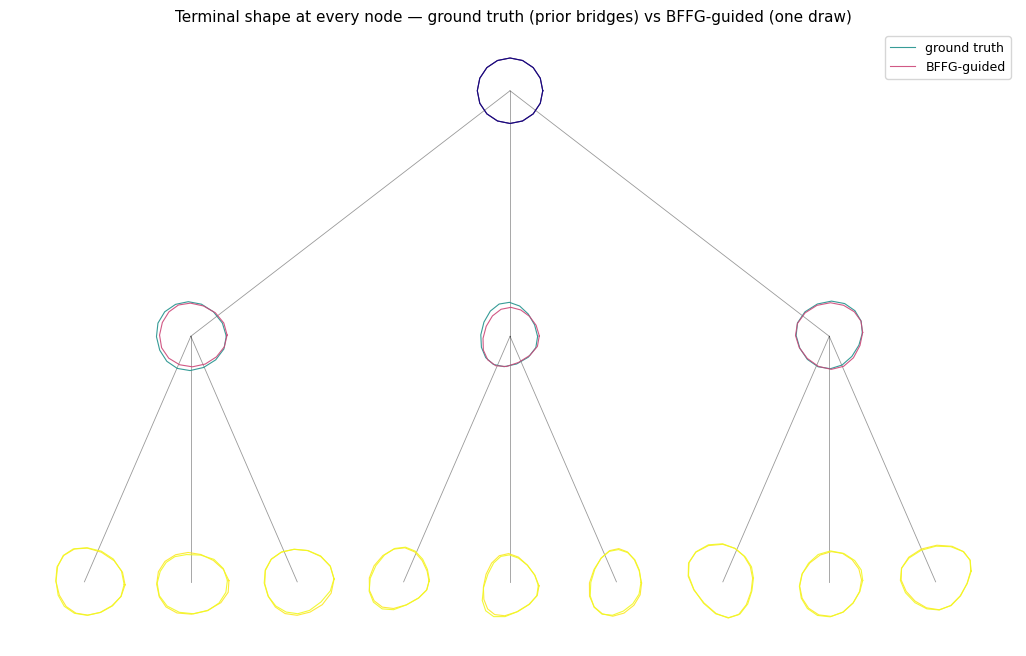

In [8]:
def _dfs_x_positions(topo):
    xs = np.zeros(topo.size)
    next_leaf = [0]
    n_leaves = int(topo.is_leaf.sum())
    def visit(node):
        if topo.is_leaf[node]:
            xs[node] = next_leaf[0] / max(1, n_leaves - 1); next_leaf[0] += 1
            return xs[node]
        children = [i for i in range(1, topo.size) if int(topo.parents[i]) == int(node)]
        cx = [visit(c) for c in children]
        xs[node] = float(np.mean(cx)); return xs[node]
    visit(0)
    return xs


def plot_tree_shapes(values_dict, title=None, scaling=0.4, figsize=(18, 8)):
    pos = np.zeros((topo.size, 2))
    pos[:, 0] = _dfs_x_positions(topo) * (topo.size * 0.8)
    pos[:, 1] = -np.asarray(topo.node_depths) * 3.0
    cmaps = ["viridis", "plasma", "inferno"]
    fig, ax = plt.subplots(figsize=figsize)
    for i in range(1, topo.size):
        p = int(topo.parents[i])
        ax.plot([pos[p, 0], pos[i, 0]], [pos[p, 1], pos[i, 1]], "k-", lw=0.6, alpha=0.4, zorder=1)
    for ci, (key, vals) in enumerate(values_dict.items()):
        cmap = plt.get_cmap(cmaps[ci % len(cmaps)])
        for i in range(topo.size):
            v = np.asarray(vals[i])
            terminal = v[-1] if v.ndim == 2 else v
            pts = terminal.reshape((N_LANDMARKS, D_PER_LANDMARK))
            closed = np.vstack([pts, pts[:1]])
            c = cmap(int(topo.node_depths[i]) / max(1, topo.depth))
            ax.plot(closed[:, 0] * scaling + pos[i, 0],
                    closed[:, 1] * scaling + pos[i, 1],
                    "-", color=c, lw=0.8, alpha=0.9, zorder=2,
                    label=key if i == 1 else None)
    if title: ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9); ax.set_aspect("equal"); ax.set_axis_off()
    return fig, ax


plot_tree_shapes(
    {"ground truth": ground_truth_vals, "BFFG-guided": guided_vals},
    title="Terminal shape at every node — ground truth (prior bridges) vs BFFG-guided (one draw)"
)
plt.show()


## 3. The Theorem-23 importance weight is no longer 0

Notebook 05 verified $\sum \log w \equiv 0$ across noise draws (Theorem-14 collapse for linear-Gaussian transitions). Here the **true** SDE has state-dependent diffusion $\sigma(X)$ while the **auxiliary** uses $\sigma(\text{root})$ — so the Theorem-23 correction has work to do, and we see real variation in $\sum \log w$ across noise draws.

50 noise draws at θ_true:
  sum log_corr — mean =   -2.467, std = 3.105
  (in notebook 05's linear case this would be identically 0)


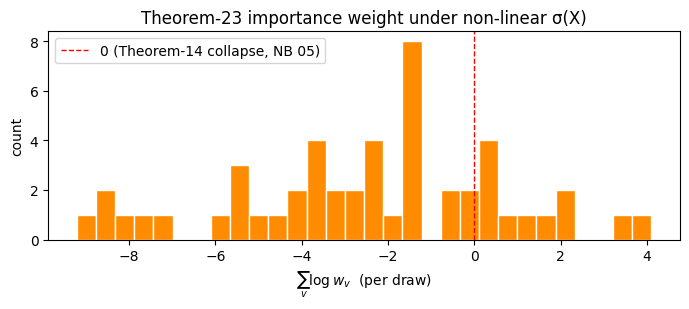

In [9]:
keys = jax.random.split(jax.random.PRNGKey(11), 50)
lt_true = jnp.log(jnp.array([K_ALPHA_TRUE, K_SIGMA_TRUE]))
sums = []
for k in keys:
    z = jax.random.normal(k, (N_NODES * N_STEPS * D,), dtype=jnp.float32)
    _, slc, _ = bffg_guided_forward(z, lt_true)
    sums.append(float(slc))
sums = np.asarray(sums)

print(f"50 noise draws at θ_true:")
print(f"  sum log_corr — mean = {sums.mean():+8.3f}, std = {sums.std():.3f}")
print(f"  (in notebook 05's linear case this would be identically 0)")

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(sums, bins=30, color="darkorange", edgecolor="white")
ax.axvline(0, color="r", ls="--", lw=1, label="0 (Theorem-14 collapse, NB 05)")
ax.set_xlabel(r"$\sum_v \log w_v$  (per draw)")
ax.set_ylabel("count")
ax.set_title("Theorem-23 importance weight under non-linear σ(X)")
ax.legend(); plt.tight_layout(); plt.show()


## 4. NumPyro model

Three sites:

- $\log k_\alpha$, $\log k_\sigma$ with weakly-informative log-normal priors — $\mathcal{N}(\log 0.2,\,0.7^2)$ and $\mathcal{N}(\log 0.5,\,0.7^2)$ (positive parameters via the log-transform).
- $z$ — the per-step Brownian-noise field flattened to one vector of length $N_\text{nodes} \cdot N_\text{steps} \cdot D$.

The BFFG-implied log-density goes in via `numpyro.factor`:

$$\text{factor}_\text{bffg} \;=\; \mathrm{log\_norm\_root}(\log\theta) \;+\; \sum_v \log w_v(z, \log\theta).$$

`log_norm_root` is the BFFG estimate of the marginal log-likelihood, $\log h(x_\text{root})$, read off the canonical message at the pinned root.

In [10]:
N_Z = N_NODES * N_STEPS * D
print(f"noise dimension: {N_Z}")


def model():
    log_k_alpha = numpyro.sample(
        "log_k_alpha", dist.Normal(PRIOR_LOG_MEAN["log_k_alpha"], PRIOR_STD["log_k_alpha"])
    )
    log_k_sigma = numpyro.sample(
        "log_k_sigma", dist.Normal(PRIOR_LOG_MEAN["log_k_sigma"], PRIOR_STD["log_k_sigma"])
    )
    z = numpyro.sample("z", dist.Normal(jnp.zeros(N_Z), 1.0).to_event(1))
    log_theta = jnp.stack([log_k_alpha, log_k_sigma])
    _, sum_log_corr, log_norm_root = bffg_guided_forward(z, log_theta)
    numpyro.factor("bffg", log_norm_root + sum_log_corr)


mi = initialize_model(jax.random.PRNGKey(0), model, validate_grad=False)
potential_fn = mi.potential_fn
init_u = {
    "log_k_alpha": jnp.log(jnp.array(K_ALPHA_TRUE)),
    "log_k_sigma": jnp.log(jnp.array(K_SIGMA_TRUE)),
    "z": jnp.zeros(N_Z),
}
print(f"U at (θ_true, z=0) = {float(potential_fn(init_u)):.4f}")


noise dimension: 41600
U at (θ_true, z=0) = 37808.5000


## 5. Custom `RWpCNKernel` — same pattern as notebook 05

Two-block Metropolis-within-Gibbs:

- **pCN block** on `z`: $z' = \sqrt{1-\beta^2}\,z + \beta\,\varepsilon$, reversible w.r.t. $\mathcal{N}(0, I)$. One-line correction to subtract the $z$-prior that `potential_fn` bakes in.
- **RW block** on $(\log k_\alpha, \log k_\sigma)$: symmetric Gaussian random walk, standard accept ratio.

The kernel class is structurally identical to notebook 05's — only the `param_sites` tuple now has two 1-D entries instead of one 2-D entry.

In [11]:
RWpCNState = namedtuple("RWpCNState", ["u", "potential_energy", "accept", "rng_key"])


def _std_normal_logpdf(x):
    return -0.5 * jnp.sum(x ** 2)


class RWpCNKernel(MCMCKernel):
    sample_field = "u"

    def __init__(
        self,
        potential_fn,
        *,
        eta,
        rw_scale,
        noise_site="z",
        param_sites=("log_k_alpha", "log_k_sigma"),
    ):
        self._potential_fn = potential_fn
        self._eta = eta
        self._rw_scale = rw_scale
        self._noise_site = noise_site
        self._param_sites = tuple(param_sites)

    def init(self, rng_key, num_warmup, init_params, model_args, model_kwargs):
        if init_params is None:
            raise ValueError("RWpCNKernel needs explicit init_params (a dict per site).")
        return RWpCNState(init_params, self._potential_fn(init_params), jnp.zeros(2), rng_key)

    def postprocess_fn(self, model_args, model_kwargs):
        return lambda x, *a, **k: x

    def sample(self, state, model_args, model_kwargs):
        u = dict(state.u)
        U = state.potential_energy
        k_pcn, k_pcn_acc, k_rw, k_rw_acc, k_next = jax.random.split(state.rng_key, 5)

        # pCN on noise (params fixed); subtract z-prior delta since U bakes it in.
        z = u[self._noise_site]
        z_prop = self._eta * z + jnp.sqrt(1.0 - self._eta ** 2) * jax.random.normal(k_pcn, z.shape)
        U_prop = self._potential_fn({**u, self._noise_site: z_prop})
        log_alpha = (
            -(U_prop - U)
            - (_std_normal_logpdf(z_prop) - _std_normal_logpdf(z))
        )
        acc_z = jnp.log(jax.random.uniform(k_pcn_acc)) < log_alpha
        u[self._noise_site] = jnp.where(acc_z, z_prop, z)
        U = jnp.where(acc_z, U_prop, U)

        # RW on each param site (noise fixed); symmetric, no correction.
        rw_keys = jax.random.split(k_rw, len(self._param_sites))
        u_prop = dict(u)
        for site, key in zip(self._param_sites, rw_keys):
            u_prop[site] = u[site] + self._rw_scale * jax.random.normal(key, u[site].shape)
        U_prop = self._potential_fn(u_prop)
        acc_th = jnp.log(jax.random.uniform(k_rw_acc)) < -(U_prop - U)
        for site in self._param_sites:
            u[site] = jnp.where(acc_th, u_prop[site], u[site])
        U = jnp.where(acc_th, U_prop, U)

        return RWpCNState(u, U, jnp.array([acc_z, acc_th], dtype=jnp.float32), k_next)


## 6. Run the chain

Single chain started at the truth; the RW block explores $\theta$ from there while pCN moves the noise field $z$. For a non-linear SDE the RW acceptance is driven by the *combined* movement of `log_norm_root` and $\sum \log w$, which depends on both the latent bridge and the parameters — so the chain is genuinely informative.

We set `num_warmup=0`: this fixed kernel does no warmup adaptation, and NumPyro drops warmup draws from `get_samples()`, so a non-zero warmup would silently hide the (fast) convergence transient. We keep the full chain and burn in during post-processing instead.

In [14]:
# num_warmup=0: NumPyro drops warmup draws from get_samples() and this fixed
# kernel does no warmup adaptation, so a non-zero warmup would hide the (fast)
# convergence transient. Keep the full chain; burn in during post-processing.
N_WARMUP = 0
N_SAMPLES = 2000

kernel = RWpCNKernel(potential_fn, eta=PCN_ETA, rw_scale=RW_SCALE)
init_u = {
    "log_k_alpha": jnp.log(jnp.array(0.5, dtype=jnp.float32)),
    "log_k_sigma": jnp.log(jnp.array(0.5, dtype=jnp.float32)),
    "z": jax.random.normal(jax.random.PRNGKey(33), (N_Z,), dtype=jnp.float32),
}

mc = MCMC(
    kernel,
    num_warmup=N_WARMUP,
    num_samples=N_SAMPLES,
    num_chains=1,
    progress_bar=False,
)
t0 = time.perf_counter()
mc.run(jax.random.PRNGKey(7), init_params=init_u, extra_fields=("accept", "potential_energy"))
elapsed = time.perf_counter() - t0

samples = mc.get_samples()
acc = np.asarray(mc.get_extra_fields()["accept"])
# potential_energy is U = -log joint, dominated by the z-prior normaliser
# ½·N_Z·log(2π) (~4e4 here), not the likelihood. The meaningful log-target is
# reconstructed in the trace-plot cell.
log_likeli = np.asarray(mc.get_extra_fields()["potential_energy"])
log_k_alpha = np.asarray(samples["log_k_alpha"])
log_k_sigma = np.asarray(samples["log_k_sigma"])

print(f"RW/pCN: {elapsed:.1f}s   {N_SAMPLES} samples")
print(f"  acc pCN = {acc[..., 0].mean():.4f}")
print(f"  acc RW  = {acc[..., 1].mean():.4f}  (target band 0.20-0.55)")
print(f"  mean potential U (incl. z-prior) = {log_likeli.mean():.1f}")

RW/pCN: 1.7s   2000 samples
  acc pCN = 0.1620
  acc RW  = 0.4025  (target band 0.20-0.55)
  mean potential U (incl. z-prior) = 58603.9


## 7. Trace plots and posterior summaries

NumPyro's `potential_energy` is $U = -\log$ joint and bakes in the standard-normal $z$-prior, whose normaliser $\tfrac12 N_Z\log 2\pi$ (here $\sim\!4\times10^4$) and quadratic $\tfrac12\lVert z\rVert^2$ dwarf the BFFG log-likelihood and have the wrong sign for a "target". The pCN block cancels that prior in its acceptance, so we add it back to recover the meaningful log-target $\log p(y\mid\theta) + \log p(\theta)$ — an $O(10^2)$ quantity with a clear convergence trend.

Posterior summaries (after burn-in = 500):
  k_alpha:  mean=0.050 ± 0.004,  truth = 0.05
  k_sigma:  mean=0.262 ± 0.016,  truth = 0.25
  log target:  start=-908.8  ->  post-burn mean=426.9


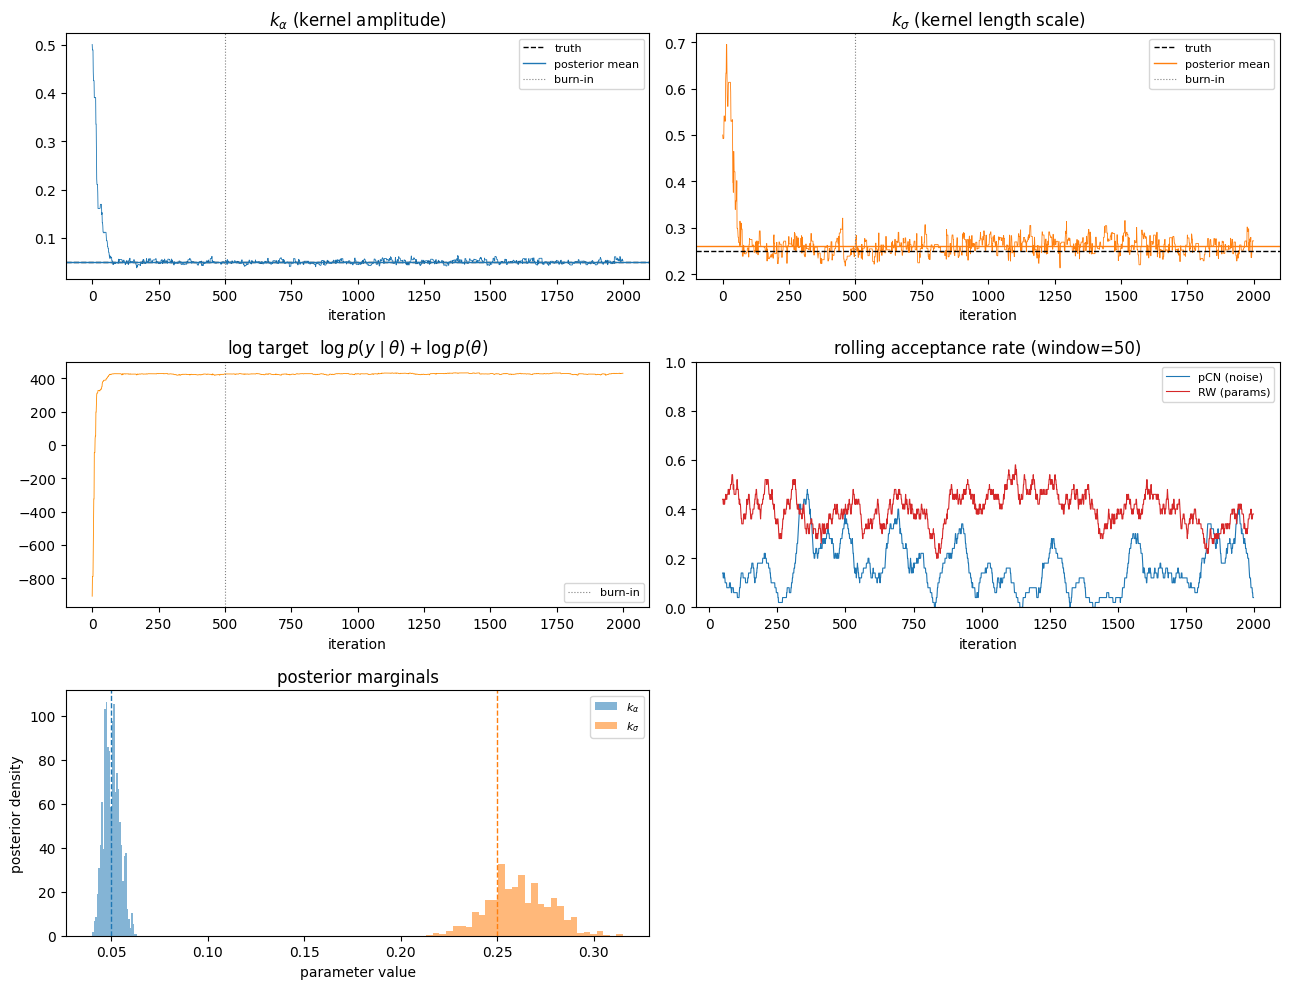

In [15]:
burn = 500
k_alpha_post = np.exp(log_k_alpha[burn:])
k_sigma_post = np.exp(log_k_sigma[burn:])

# Reconstruct the meaningful log-target from the saved trace. U = -log joint
# bakes in the z-prior (constant ½·N_Z·log(2π) ~4e4 plus a drifting ½Σz²), which
# buries the BFFG log-likelihood. pCN cancels that prior in its acceptance, so
# adding it back is exact and recovers log p(y | θ) + log p(θ) ~ O(1e2).
z_arr = np.asarray(samples["z"])
N_Z_ = z_arr.shape[-1]
z_sq = np.einsum("ij,ij->i", z_arr, z_arr)                 # Σz² per draw
log_target = -log_likeli + 0.5 * z_sq + 0.5 * N_Z_ * np.log(2.0 * np.pi)

print(f"Posterior summaries (after burn-in = {burn}):")
for name, post, truth in [
    ("k_alpha", k_alpha_post, K_ALPHA_TRUE),
    ("k_sigma", k_sigma_post, K_SIGMA_TRUE),
]:
    print(f"  {name}:  mean={post.mean():.3f} ± {post.std():.3f},  truth = {truth}")
print(f"  log target:  start={log_target[0]:.1f}  ->  post-burn mean={log_target[burn:].mean():.1f}")

fig, axes = plt.subplots(3, 2, figsize=(13, 10))

ax = axes[0, 0]
ax.plot(np.exp(log_k_alpha), lw=0.6, color="C0")
ax.axhline(K_ALPHA_TRUE, ls="--", color="k", lw=1, label="truth")
ax.axhline(k_alpha_post.mean(), ls="-", color="C0", lw=1, label="posterior mean")
ax.axvline(burn, ls=":", color="gray", lw=0.8, label="burn-in")
ax.set_title(r"$k_\alpha$ (kernel amplitude)"); ax.set_xlabel("iteration"); ax.legend(fontsize=8)

ax = axes[0, 1]
ax.plot(np.exp(log_k_sigma), lw=0.6, color="C1")
ax.axhline(K_SIGMA_TRUE, ls="--", color="k", lw=1, label="truth")
ax.axhline(k_sigma_post.mean(), ls="-", color="C1", lw=1, label="posterior mean")
ax.axvline(burn, ls=":", color="gray", lw=0.8, label="burn-in")
ax.set_title(r"$k_\sigma$ (kernel length scale)"); ax.set_xlabel("iteration"); ax.legend(fontsize=8)

ax = axes[1, 0]
ax.plot(log_target, lw=0.6, color="darkorange")
ax.axvline(burn, ls=":", color="gray", lw=0.8, label="burn-in")
ax.set_title(r"log target  $\log p(y\mid\theta) + \log p(\theta)$"); ax.set_xlabel("iteration"); ax.legend(fontsize=8)

ax = axes[1, 1]
window = 50
acc_pcn = np.convolve(acc[:, 0], np.ones(window) / window, mode="valid")
acc_rw = np.convolve(acc[:, 1], np.ones(window) / window, mode="valid")
xs = np.arange(window - 1, len(acc))
ax.plot(xs, acc_pcn, lw=0.8, color="C0", label="pCN (noise)")
ax.plot(xs, acc_rw, lw=0.8, color="C3", label="RW (params)")
ax.set_title(f"rolling acceptance rate (window={window})"); ax.set_xlabel("iteration")
ax.set_ylim(0, 1); ax.legend(fontsize=8)

ax = axes[2, 0]
for post, name, truth, mean_lab in [
    (k_alpha_post, r"$k_\alpha$", K_ALPHA_TRUE, "posterior mean"),
    (k_sigma_post, r"$k_\sigma$", K_SIGMA_TRUE, None),
]:
    ax.hist(post, bins=30, density=True, alpha=0.55, label=name)
ax.axvline(K_ALPHA_TRUE, color="C0", ls="--", lw=1)
ax.axvline(K_SIGMA_TRUE, color="C1", ls="--", lw=1)
ax.set_xlabel("parameter value"); ax.set_ylabel("posterior density")
ax.set_title("posterior marginals"); ax.legend(fontsize=8)

ax = axes[2, 1]
ax.set_axis_off()

plt.tight_layout(); plt.show()

## 8. Multi-chain convergence — Gelman–Rubin $\hat R$

A single well-mixing chain is necessary but not sufficient. We run several chains from **overdispersed** starts and check they agree, via the Gelman–Rubin $\hat R$ (between- vs within-chain variance) and the effective sample size.

`num_chains` only sets the count; *how* they run is `chain_method` — and none of the options is OS multi-threading:

- `"vectorized"` (`jax.vmap`) hands the kernel a *batched* state with a leading chain axis, so the kernel must be written to handle it. NumPyro's built-in NUTS/HMC are; our hand-written `RWpCNKernel` calls `potential_fn` on whatever state it gets, so a batched state breaks it.
- `"parallel"` (`jax.pmap`) runs one chain per XLA device — needs `num_chains` devices (on CPU: `numpyro.set_host_device_count(...)` *before* JAX starts).
- `"sequential"` runs the chains through a compiled `lax.map` over the chain axis; each chain sees a single-chain state, so the custom kernel works unchanged on one device.

We use **`"sequential"`** here. Either way each chain gets its own overdispersed $(\log k_\alpha, \log k_\sigma)$ and noise field via an `init_params` whose leaves carry a leading `(num_chains,)` axis. (To spread a custom kernel across CPU cores instead, use `"parallel"` after `numpyro.set_host_device_count(N_CHAINS)`.)

NumPyro keeps every chain's full trace — including the large noise field $z$ — in memory, so drop `N_CHAINS` or `N_SAMPLES` if it gets tight.

In [16]:
N_CHAINS = 4

# Overdispersed per-chain starts bracketing the truth (log space) plus an
# independent noise field per chain. Each init_params leaf carries a leading
# (N_CHAINS,) axis; vectorized/parallel chains slice along it.
ka_init = jnp.log(jnp.array([0.05, 0.10, 0.20, 0.50], dtype=jnp.float32))  # truth 0.05
ks_init = jnp.log(jnp.array([0.10, 0.20, 0.30, 0.50], dtype=jnp.float32))   # truth 0.25
z_keys = jax.random.split(jax.random.PRNGKey(2024), N_CHAINS)
z_init = jax.vmap(lambda k: jax.random.normal(k, (N_Z,), dtype=jnp.float32))(z_keys)
init_chains = {"log_k_alpha": ka_init, "log_k_sigma": ks_init, "z": z_init}

mc_multi = MCMC(
    RWpCNKernel(potential_fn, eta=PCN_ETA, rw_scale=RW_SCALE),
    num_warmup=0,
    num_samples=N_SAMPLES,
    num_chains=N_CHAINS,
    chain_method="parallel", 
    progress_bar=False,
)
t0 = time.perf_counter()
mc_multi.run(jax.random.PRNGKey(404), init_params=init_chains, extra_fields=("accept",))
print(f"{N_CHAINS} chains x {N_SAMPLES} samples (parallel): {time.perf_counter() - t0:.1f}s")

samples_mc = mc_multi.get_samples(group_by_chain=True)            # leaves: (N_CHAINS, N_SAMPLES, ...)
acc_mc = np.asarray(mc_multi.get_extra_fields(group_by_chain=True)["accept"])  # (N_CHAINS, N_SAMPLES, 2)
log_ka_c = np.asarray(samples_mc["log_k_alpha"])                  # (N_CHAINS, N_SAMPLES)
log_ks_c = np.asarray(samples_mc["log_k_sigma"])
for c in range(N_CHAINS):
    print(f"  chain {c}: acc pCN={acc_mc[c, :, 0].mean():.3f}  acc RW={acc_mc[c, :, 1].mean():.3f}")

4 chains x 2000 samples (parallel): 2.9s
  chain 0: acc pCN=0.145  acc RW=0.414
  chain 1: acc pCN=0.079  acc RW=0.421
  chain 2: acc pCN=0.177  acc RW=0.400
  chain 3: acc pCN=0.086  acc RW=0.405


After burn-in = 500  (4 chains x 1500 draws):
  k_alpha:  R-hat = 1.0111  (converged),  ESS = 375
  k_sigma:  R-hat = 1.0182  (converged),  ESS = 161


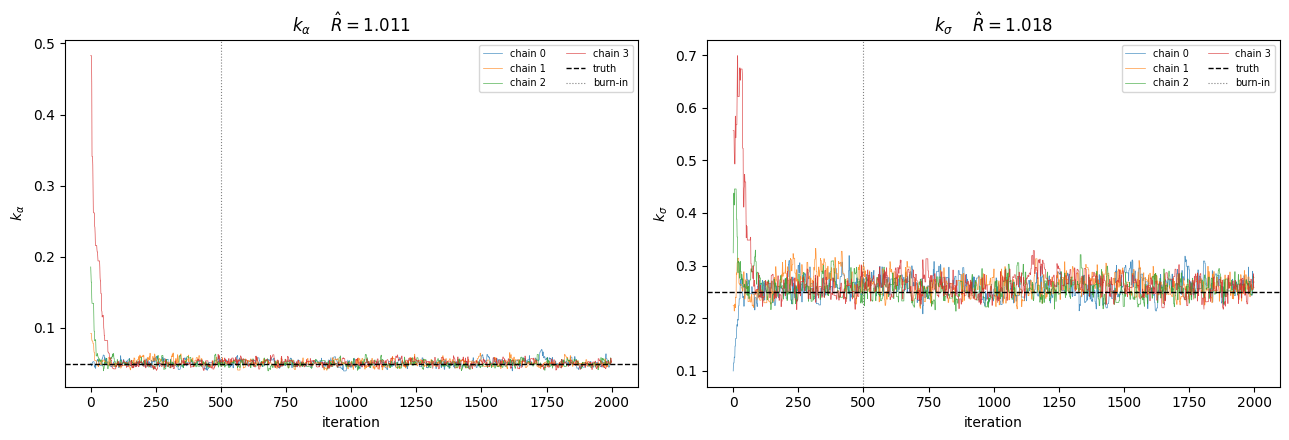

In [17]:
burn = 500

# Gelman-Rubin R-hat and ESS on the post-burn-in chains, in the sampled (log)
# space. numpyro's diagnostics take a (num_chains, num_samples) array.
rhat = {"k_alpha": float(gelman_rubin(log_ka_c[:, burn:])),
        "k_sigma": float(gelman_rubin(log_ks_c[:, burn:]))}
ess = {"k_alpha": float(effective_sample_size(log_ka_c[:, burn:])),
       "k_sigma": float(effective_sample_size(log_ks_c[:, burn:]))}

print(f"After burn-in = {burn}  ({N_CHAINS} chains x {N_SAMPLES - burn} draws):")
for name in ("k_alpha", "k_sigma"):
    flag = "converged" if rhat[name] < 1.1 else "NOT converged (run longer)"
    print(f"  {name}:  R-hat = {rhat[name]:.4f}  ({flag}),  ESS = {ess[name]:.0f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, log_c, truth, latex, rh in [
    (axes[0], log_ka_c, K_ALPHA_TRUE, r"k_\alpha", rhat["k_alpha"]),
    (axes[1], log_ks_c, K_SIGMA_TRUE, r"k_\sigma", rhat["k_sigma"]),
]:
    for c in range(N_CHAINS):
        ax.plot(np.exp(log_c[c]), lw=0.5, alpha=0.8, label=f"chain {c}")
    ax.axhline(truth, color="k", ls="--", lw=1, label="truth")
    ax.axvline(burn, color="gray", ls=":", lw=0.8, label="burn-in")
    ax.set_title(rf"${latex}$    $\hat R = {rh:.3f}$")
    ax.set_xlabel("iteration"); ax.set_ylabel(rf"${latex}$")
    ax.legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.show()

## Recap

1. **`hyperiax.prebuilt.bffg` continuous-edge sweeps** (`continuous_forward_sweep` / `continuous_bf_sweep` / `continuous_refine_anchor` / `continuous_fg_sweep`) compose into a pure $(z, \log\theta) \mapsto (\text{bridges}, \sum \log w, \text{log\_norm\_root})$ map. The `log_norm` field tracks the canonical-message constant the BFFG up-sweep accumulates; evaluated at the pinned root it is the BFFG estimate of $\log p(y \mid \theta)$.
2. **Non-linear σ(X) ⇒ Theorem-14 collapse breaks.** With the auxiliary linearised per edge (anchor refined toward the posterior mean), $\sum \log w$ varies meaningfully across noise draws — a std of a few units at the truth, versus identically 0 in the linear case — and pCN+RW jointly target the BFFG posterior.
3. **The MCMC kernel from notebook 05 ports verbatim.** Only the `param_sites` argument changes (two 1-D log-parameter sites instead of one 2-D `log_theta`). NumPyro's `MCMC` driver runs the same two-block Metropolis-within-Gibbs scheme.
4. **End-to-end inference works.** On a 13-node tree with 16 landmarks × 2-D state and 100 SDE steps per edge, 2000 collected draws (`num_warmup=0`, burn-in 500) concentrate around the data-generating $(k_\alpha, k_\sigma) = (0.05, 0.25)$.

Comparing the three BFFG notebooks:

| Notebook | Transition | BFFG correction | Inference engine |
|---|---|---|---|
| [05](05_gaussian_bffg.ipynb) | linear Gaussian | $\sum \log w \equiv 0$ (Th. 14 collapse) | RW + pCN via NumPyro |
| [06](06_gaussian_nuts.ipynb) | linear Gaussian (same) | (irrelevant — closed form) | NUTS via NumPyro |
| 07 (this) | non-linear SDE | $\sum \log w \ne 0$ (Th. 23, real correction) | RW + pCN via NumPyro |

## References

- van der Meulen, F. H. & Sommer, S. (2025). *Backward Filtering Forward Guiding.* JMLR **26**(281), 1–51. [arXiv:2505.18239](https://arxiv.org/abs/2505.18239) — §7.1, Theorem 23, Remark 24.
- Cotter, S. L., Roberts, G. O., Stuart, A. M., White, D. (2013). *MCMC methods for functions.* Statistical Science **28**(3), 424–446. — pCN.